# Problem

Build an image classification model on CIFAR-10 and analyze performance across architectures and training strategies. (Do it with both ANN & CNN)


# Installing All The Dependency

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,BatchNormalization,RandomFlip,RandomRotation,RandomZoom
from tensorflow.keras.callbacks import EarlyStopping

# Downloading Dataset

In [ ]:
from tensorflow.keras.datasets import cifar10

In [ ]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data();
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape);

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4267s 25us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


# Normalizing The Image
**normalization helps us to get a Stable Gradient**

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

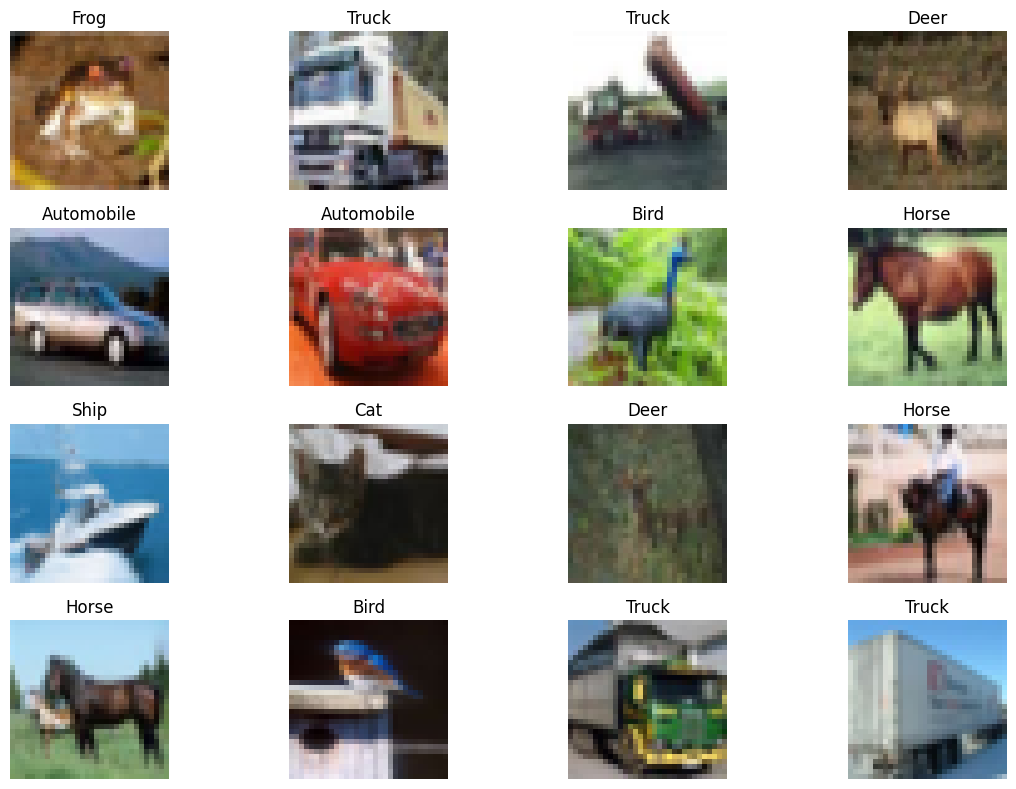

In [ ]:
classes = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]
plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# ANN
**An Artificial Neural Network consists of an input layer, one or more hidden layers, and an output layer. Each neuron computes a weighted sum of its inputs, adds a bias, applies an activation function like ReLU, and passes the result to the next layer. During training, the network performs forward propagation to make predictions, calculates a loss, uses backpropagation to compute gradients, and updates the weights with gradient descent. Repeating this process over many epochs allows the network to learn complex patterns in the data.**

In [ ]:
ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512,Activation("relu"),Dropout(0.3)),
    Dense(256,Activation("relu"),Dropout(0.3)),
    Dense(10,Activation("softmax"))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
ann_model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])


In [ ]:
history_Ann = ann_model.fit(x_train,
                            y_train,
                            validation_data=(x_test, y_test),
                            epochs=10,
                            batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3261 - loss: 1.8758 - val_accuracy: 0.3805 - val_loss: 1.7144
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3995 - loss: 1.6698 - val_accuracy: 0.4264 - val_loss: 1.6031
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4342 - loss: 1.5858 - val_accuracy: 0.4564 - val_loss: 1.5405
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4587 - loss: 1.5214 - val_accuracy: 0.4573 - val_loss: 1.5084
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4738 - loss: 1.4834 - val_accuracy: 0.4530 - val_loss: 1.5401
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4847 - loss: 1.4472 - val_accuracy: 0.4732 - val_loss: 1.4811
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4961 - loss: 1.4153 - val_accuracy: 0.4741 - val_loss: 1.4793
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5041 - loss: 1.3948 - val_accuracy: 0.

# CNN

**A CNN is a deep learning model designed for image data. It uses convolution layers to automatically learn features like edges, textures, and shapes, ReLU to introduce non-linearity, and pooling layers to reduce image size while preserving important information. The extracted features are then flattened and passed to fully connected layers for classification. CNNs perform better than ANNs on images because they preserve spatial relationships, require fewer parameters through weight sharing, and automatically learn hierarchical features**

In [ ]:
cnn_model = Sequential([
    Conv2D(32,(3,3),padding="same",input_shape=(32,32,3)),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(64,(3,3),padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Flatten(),
    Dense(256,Activation("relu")),
    Dropout(0.5),
    Dense(10,Activation("softmax"))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
hsitory_cnn=cnn_model.fit(x_train,y_train,
              validation_data=(x_test,y_test),
              epochs=10,
              batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4222 - loss: 1.6291 - val_accuracy: 0.5378 - val_loss: 1.3598
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5546 - loss: 1.2581 - val_accuracy: 0.5907 - val_loss: 1.1347
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6169 - loss: 1.0913 - val_accuracy: 0.6643 - val_loss: 0.9547
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6578 - loss: 0.9818 - val_accuracy: 0.6887 - val_loss: 0.9089
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6911 - loss: 0.8912 - val_accuracy: 0.6606 - val_loss: 1.0060
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7161 - loss: 0.8164 - val_accuracy: 0.6848 - val_loss: 0.9274
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7389 - loss: 0.7434 - val_accuracy: 0.6882 - val_loss: 0.9145
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7582 - loss: 0.6879 - val_accuracy: 

**Graph to show the differnce between ANN and CNN in term of Accuracy**

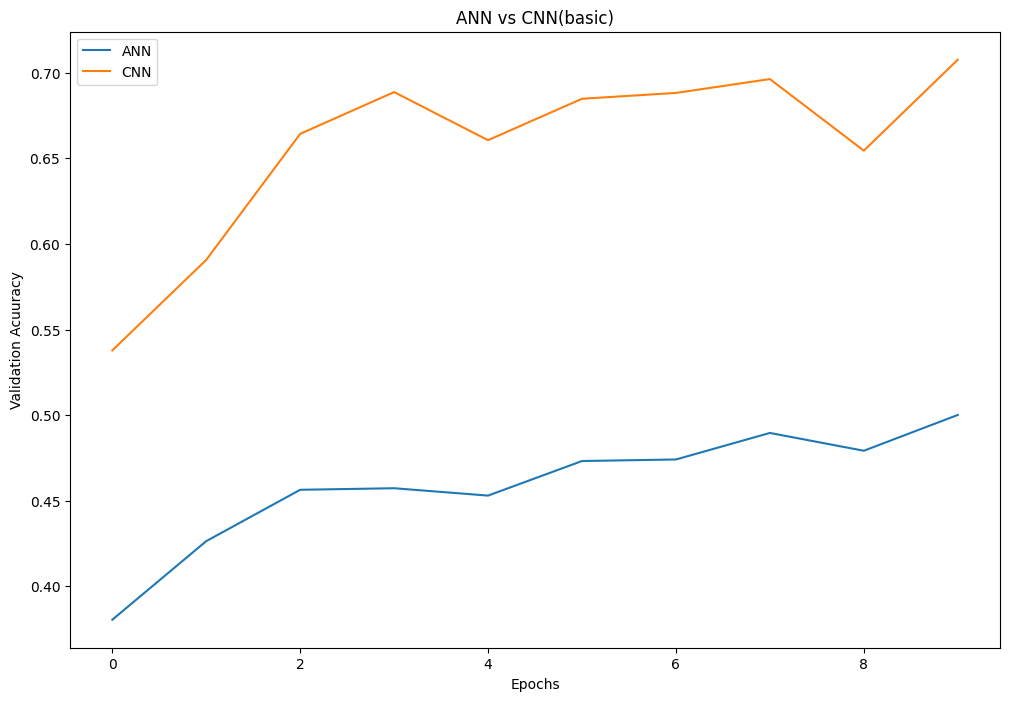

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(history_Ann.history['val_accuracy'], label='ANN')
plt.plot(hsitory_cnn.history['val_accuracy'], label='CNN')
plt.xlabel('Epochs')
plt.ylabel('Validation Acuuracy')
plt.title('ANN vs CNN(basic)')
plt.legend()
plt.show()

## Observation

The graph shows that the CNN consistently outperformed the ANN throughout the training process. The CNN's validation accuracy increased rapidly and stabilized around 70%, while the ANN improved slowly and reached only 50% by the final epoch. This demonstrates that CNN is more effective for image classification because it can learn spatial features directly from images, whereas ANN loses this information after flattening the input.

# Data Augmentation

In [ ]:
data_Augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)
])

In [ ]:
cnn_advance_model = Sequential([
    data_Augmentation,
    Conv2D(32,(3,3),padding="same",input_shape=(32,32,3)),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(64,(3,3),padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(128,(3,3),padding="same"),
    Activation("relu"),
    BatchNormalization(),
    MaxPooling2D(),
    Flatten(),
    Dense(512,Activation("relu")),
    Dropout(0.5),
    Dense(256,Activation("relu")),
    Dropout(0.5),
    Dense(10,Activation("softmax"))
])

In [ ]:
cnn_advance_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=3,
                               restore_best_weights=True)

In [ ]:
history_augmented_model = cnn_advance_model.fit(x_train, y_train,
                                                  validation_data=(x_test, y_test),
                                                  epochs=20,
                                                  batch_size=64,
                                                  callbacks=[early_stopping])

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.3013 - loss: 1.9686 - val_accuracy: 0.2897 - val_loss: 2.0045
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.3954 - loss: 1.6775 - val_accuracy: 0.4517 - val_loss: 1.5870
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4444 - loss: 1.5506 - val_accuracy: 0.4870 - val_loss: 1.4634
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4766 - loss: 1.4740 - val_accuracy: 0.5050 - val_loss: 1.4194
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5018 - loss: 1.4036 - val_accuracy: 0.5545 - val_loss: 1.2554
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.5264 - loss: 1.3487 - val_accuracy: 0.5482 - val_loss: 1.2567
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5399 - loss: 1.3135 - val_accuracy: 0.5741 - val_loss: 1.2174
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5559 - loss: 1.2759 - 

## Observation

Since the validation loss continued to improve until the later epochs, the model had not completely converged within 20 epochs. Increasing the number of epochs while using EarlyStopping could allow the model to achieve better performance without risking excessive overfitting.

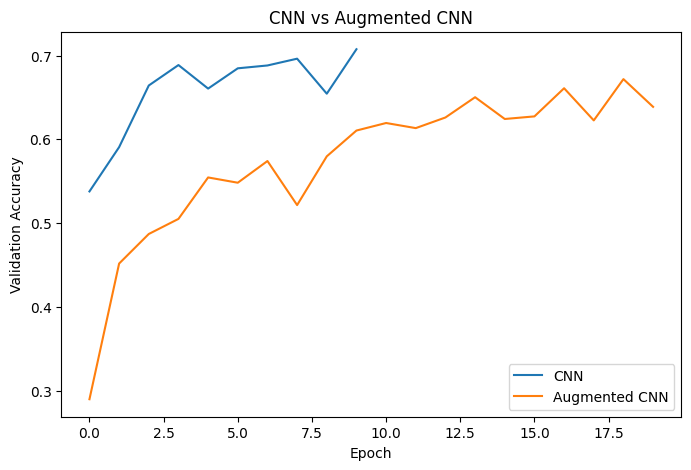

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(hsitory_cnn.history['val_accuracy'],
         label='CNN')

plt.plot(history_augmented_model.history['val_accuracy'],
         label='Augmented CNN')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("CNN vs Augmented CNN")
plt.legend()
plt.show()

## Observation

The graph shows that the standard CNN consistently achieved higher validation accuracy than the Augmented CNN across all epochs. The CNN quickly reached around 71% validation accuracy by the final epoch, while the Augmented CNN improved gradually from 29% to about 64%. Although data augmentation helped the model learn more steadily and reduced fluctuations, it did not outperform the standard CNN in this training setup. This suggests that the standard CNN learned the dataset more effectively under the given training conditions.

In [ ]:

results = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Train Accuracy": [
        history_Ann.history["accuracy"][-1],
        hsitory_cnn.history["accuracy"][-1],
        history_augmented_model.history["accuracy"][-1]
    ],
    "Validation Accuracy": [
        history_Ann.history["val_accuracy"][-1],
        hsitory_cnn.history["val_accuracy"][-1],
        history_augmented_model.history["val_accuracy"][-1]
    ]
})
print(results)

           Model  Train Accuracy  Validation Accuracy
0            ANN         0.52072               0.5001
1            CNN         0.79408               0.7076
2  Augmented CNN         0.64762               0.6388


# Observation

The **CNN** achieved the highest performance with **79.41% training accuracy** and **70.76% validation accuracy**, making it the best model for image classification. The **ANN** showed the lowest accuracy because it cannot effectively capture spatial features after flattening the images. The **Augmented CNN** performed better than the ANN but slightly worse than the standard CNN, suggesting that the applied data augmentation did not improve performance for this training setup.


# Result


The **CNN** outperformed both the **ANN** and the **Augmented CNN**, achieving the highest validation accuracy of **70.76%**, demonstrating its effectiveness for image classification. Although the Augmented CNN improved generalization, it did not surpass the standard CNN under the given training setup. Additionally, since the validation loss continued to improve until the final epochs, training for more epochs with **EarlyStopping** could potentially further enhance the model's performance.
